# 📊 04 — EV Advanced Statistical Analysis

## Statistical Analysis Notebook

This notebook starts from the **cleaned and renamed EV dataset** produced in Notebook 01.

**Dataset path:** `../datas/cleaned/ev_cleaned.csv`

### Objective
Apply descriptive statistics, distribution analysis, association tests, confidence intervals, hypothesis testing, effect sizes, correlation analysis, and advanced statistical diagnostics to the EV dataset.

> Statistical methods are selected according to the actual data types and business meaning of the columns. Statistical significance does not automatically imply business importance.


## 1. Statistical Roadmap

### Numerical variables
- `Model_Year`
- `Electric_Range`
- `Base_MSRP`
- `Legislative_District`
- `Vehicle_ID` is an identifier and should not be treated as a continuous measurement.

### Categorical variables
- `County`
- `City`
- `State`
- `Make`
- `Model`
- `EV_Type`
- `CAFV_Eligibility`
- `Vehicle_Location`
- `Electric_Utility`

### Identifier / geographic fields
- `VIN`
- `Postal_Code`
- `Census_Tract`

### Main statistical methods
1. Mean, median, mode
2. Range, variance, standard deviation
3. Quartiles, IQR, percentiles
4. Coefficient of variation
5. Skewness and kurtosis
6. Frequency and proportion analysis
7. Confidence intervals
8. One-sample tests
9. Two-sample tests
10. Paired tests where appropriate
11. ANOVA
12. Chi-square test of independence
13. Correlation
14. Effect sizes
15. Outlier analysis
16. Bootstrap estimation
17. Distribution diagnostics
18. Business interpretation


In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("✅ Statistical analysis libraries loaded.")


✅ Statistical analysis libraries loaded.


In [2]:
# Load cleaned dataset
file_path = Path("../datas/cleaned/ev_cleaned.csv")

if not file_path.exists():
    raise FileNotFoundError(f"Dataset not found: {file_path.resolve()}")

df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())


C:\Users\Admin\AppData\Local\Temp\ipykernel_1648\807029432.py:7: DtypeWarning: Columns (0: Postal_Code, 1: Census_Tract) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Shape: (150482, 17)


,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,Electric_Range,Base_MSRP,Vehicle_ID,Vehicle_Location,Electric_Utility,Census_Tract,Legislative_District
0,KM8K33AGXL,King,Seattle,WA,"98,103.0000",2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),"53,033,004,800.0000",43
1,1C4RJYB61N,King,Bothell,WA,"98,011.0000",2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),"53,033,021,804.0000",1
2,1C4RJYD61P,Yakima,Yakima,WA,"98,908.0000",2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,"53,077,002,900.0000",14
3,5YJ3E1EA7J,King,Kirkland,WA,"98,034.0000",2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),"53,033,021,903.0000",45
4,WBY7Z8C5XJ,Thurston,Olympia,WA,"98,501.0000",2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,"53,067,010,700.0000",22


In [3]:
# Verify columns and data types
display(pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Unique": [df[c].nunique(dropna=True) for c in df.columns],
    "Missing": [df[c].isna().sum() for c in df.columns]
}))


,Column,Dtype,Unique,Missing
0,VIN,str,9529,0
1,County,str,183,0
2,City,str,683,0
3,State,str,41,0
4,Postal_Code,object,1292,0
5,Model_Year,int64,22,0
6,Make,str,37,0
7,Model,str,127,0
8,EV_Type,str,2,0
9,CAFV_Eligibility,str,3,0


# 2. Statistical Variable Classification

Use statistical methods according to measurement type.

| Variable type | Examples | Suitable methods |
|---|---|---|
| Continuous / numeric | Electric_Range, Base_MSRP | Mean, median, SD, CI, correlation, t-test |
| Discrete numeric | Model_Year | Frequency, median, grouped comparison |
| Nominal categorical | Make, State, EV_Type | Counts, proportions, chi-square |
| Ordinal-like category | CAFV_Eligibility | Counts, proportions, chi-square |
| Identifier | VIN, Vehicle_ID | Uniqueness / duplicate analysis |
| Geographic identifier | Postal_Code, Census_Tract | Frequency / geographic grouping |

### Important
Do not calculate a mean of `VIN`, `Vehicle_ID`, ZIP/postal codes, or census tract identifiers merely because pandas can represent them numerically.


In [4]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical/string columns:", categorical_cols)


Numeric columns: ['Model_Year', 'Electric_Range', 'Base_MSRP', 'Vehicle_ID', 'Legislative_District']

Categorical/string columns: ['VIN', 'County', 'City', 'State', 'Postal_Code', 'Make', 'Model', 'EV_Type', 'CAFV_Eligibility', 'Vehicle_Location', 'Electric_Utility', 'Census_Tract']


# 3. Descriptive Statistics

Descriptive statistics are used to **summarize, describe, and understand the main characteristics of a dataset**.

## Core Formulas

### 1. Mean

The mean is the average value of the observations.

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

Where:

* \(\bar{x}\) = sample mean
* \(n\) = number of observations
* \(x_i\) = individual observation

### 2. Sample Variance

Sample variance measures how far observations are spread around the sample mean.

$$
s^2 = \frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

**Important:** For a **sample**, the denominator is \(n-1\).


### 3. Sample Standard Deviation

Standard deviation is the square root of the variance.

$$
s = \sqrt{s^2}
$$

A larger standard deviation means **greater spread/variability** in the data.

### 4. Range

Range measures the difference between the largest and smallest values.

$$
Range = X_{max}-X_{min}
$$

### 5. Coefficient of Variation (CV)

CV measures relative variability compared with the mean.

$$
CV = \frac{s}{\bar{x}}\times100
$$

**Use CV when:**

* the mean is meaningful,
* the mean is non-zero,
* and you want to compare variability between datasets with different scales or units.

### Quick Revision

| Measure                | What it tells you                    |
| ---------------------- | ------------------------------------ |
| **Mean**               | Central/average value                |
| **Variance**           | Squared spread around the mean       |
| **Standard deviation** | Typical spread around the mean       |
| **Range**              | Maximum − minimum                    |
| **CV**                 | Relative variability as a percentage |

**Exam tip:**
`Mean → Average`
`Variance → Squared spread`
`Standard deviation → Spread in original units`
`Range → Max − Min`
`CV → Relative variability (%)`

In [5]:
# Full descriptive statistics for numerical columns
desc = df[numeric_cols].describe().T

desc["variance"] = df[numeric_cols].var()
desc["range"] = df[numeric_cols].max() - df[numeric_cols].min()
desc["skewness"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurt()

display(desc)


,count,mean,std,min,25%,50%,75%,max,variance,range,skewness,kurtosis
Model_Year,"150,482.0000","2,020.0054",3.0152,"1,997.0000","2,018.0000","2,021.0000","2,023.0000","2,024.0000",9.0915,27,-0.9782,0.2354
Electric_Range,"150,482.0000",67.8778,96.2300,0.0000,0.0000,18.0000,97.0000,337.0000,"9,260.2146",337,1.2195,-0.0320
Base_MSRP,"150,482.0000","1,312.6447","9,231.3102",0.0000,0.0000,0.0000,0.0000,"845,000.0000","85,217,088.2803",845000,11.9309,518.6919
Vehicle_ID,"150,482.0000","211,112,233.3464","81,963,879.6419","4,385.0000","169,347,305.2500","215,030,630.0000","239,911,895.5000","479,254,772.0000","6,718,077,565,950,161.0000",479250387,0.8972,3.2904
Legislative_District,"150,482.0000",29.3522,14.8090,1.0000,18.0000,33.0000,43.0000,49.0000,219.3078,48,-0.4860,-1.0617


In [6]:
# Mean, median and mode
summary = pd.DataFrame(index=numeric_cols)
summary["mean"] = df[numeric_cols].mean()
summary["median"] = df[numeric_cols].median()
summary["std"] = df[numeric_cols].std()
summary["variance"] = df[numeric_cols].var()
summary["min"] = df[numeric_cols].min()
summary["max"] = df[numeric_cols].max()
summary["range"] = summary["max"] - summary["min"]
summary["CV_%"] = (summary["std"] / summary["mean"].replace(0, np.nan)) * 100

display(summary)


,mean,median,std,variance,min,max,range,CV_%
Model_Year,"2,020.0054","2,021.0000",3.0152,9.0915,1997,2024,27,0.1493
Electric_Range,67.8778,18.0000,96.2300,"9,260.2146",0,337,337,141.7694
Base_MSRP,"1,312.6447",0.0000,"9,231.3102","85,217,088.2803",0,845000,845000,703.2604
Vehicle_ID,"211,112,233.3464","215,030,630.0000","81,963,879.6419","6,718,077,565,950,161.0000",4385,479254772,479250387,38.8248
Legislative_District,29.3522,33.0000,14.8090,219.3078,1,49,48,50.4529


In [7]:
# Mode for each numeric variable
mode_table = pd.DataFrame({
    col: df[col].mode(dropna=True)
    for col in numeric_cols
})

display(mode_table)


,Model_Year,Electric_Range,Base_MSRP,Vehicle_ID,Legislative_District
0,"2,023.0000",0.0000,0.0000,4385,41.0000
1,NaN,NaN,NaN,4777,NaN
2,NaN,NaN,NaN,10286,NaN
3,NaN,NaN,NaN,10734,NaN
4,NaN,NaN,NaN,12050,NaN
...,...,...,...,...,...
150477,NaN,NaN,NaN,478926346,NaN
150478,NaN,NaN,NaN,478934571,NaN
150479,NaN,NaN,NaN,478935460,NaN
150480,NaN,NaN,NaN,479114996,NaN


# 4. Quartiles, IQR and Percentiles

**First quartile:** Q1 = 25th percentile

**Median:** Q2 = 50th percentile

**Third quartile:** Q3 = 75th percentile

**Interquartile range**

\[
IQR = Q3-Q1
\]

The IQR is robust to extreme values and is useful for identifying potential outliers.


In [8]:
# Quartile table
quartiles = df[numeric_cols].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
quartiles.columns = ["P01", "P05", "Q1", "Median", "Q3", "P95", "P99"]

quartiles["IQR"] = quartiles["Q3"] - quartiles["Q1"]

display(quartiles)


,P01,P05,Q1,Median,Q3,P95,P99,IQR
Model_Year,"2,012.0000","2,014.0000","2,018.0000","2,021.0000","2,023.0000","2,023.0000","2,023.0000",5.0000
Electric_Range,0.0000,0.0000,0.0000,18.0000,97.0000,266.0000,322.0000,97.0000
Base_MSRP,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"69,900.0000",0.0000
Vehicle_ID,"3,386,125.8800","106,054,004.5500","169,347,305.2500","215,030,630.0000","239,911,895.5000","349,070,631.5500","477,128,999.4000","70,564,590.2500"
Legislative_District,1.0000,2.0000,18.0000,33.0000,43.0000,48.0000,49.0000,25.0000


In [9]:
# IQR-based outlier counts
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)

    outlier_summary.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": mask.sum(),
        "Outlier_%": mask.mean() * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)


,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Model_Year,"2,018.0000","2,023.0000",5.0000,"2,010.5000","2,030.5000",60,0.0399
1,Electric_Range,0.0000,97.0000,97.0000,-145.5000,242.5000,10073,6.6938
2,Base_MSRP,0.0000,0.0000,0.0000,0.0000,0.0000,3455,2.2960
3,Vehicle_ID,"169,347,305.2500","239,911,895.5000","70,564,590.2500","63,500,419.8750","345,758,780.8750",13268,8.8170
4,Legislative_District,18.0000,43.0000,25.0000,-19.5000,80.5000,0,0.0000


# 5. Distribution Shape

### Skewness

A simplified interpretation:

- Skewness ≈ 0 → approximately symmetric
- Positive skew → longer right tail
- Negative skew → longer left tail

### Kurtosis

Pandas/SciPy commonly report **excess kurtosis**, where approximately normal data has kurtosis near 0.

These statistics are diagnostics, not automatic proof that a distribution is normal/non-normal.


In [10]:
# Skewness and kurtosis
shape_stats = pd.DataFrame({
    "Skewness": df[numeric_cols].skew(),
    "Excess_Kurtosis": df[numeric_cols].kurt()
})

display(shape_stats)


,Skewness,Excess_Kurtosis
Model_Year,-0.9782,0.2354
Electric_Range,1.2195,-0.0320
Base_MSRP,11.9309,518.6919
Vehicle_ID,0.8972,3.2904
Legislative_District,-0.4860,-1.0617


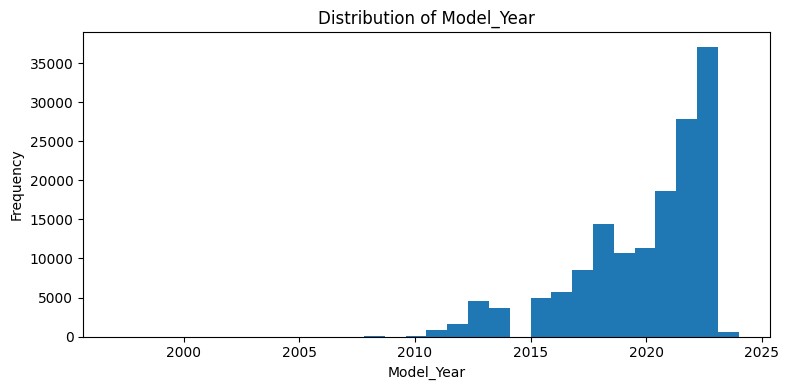

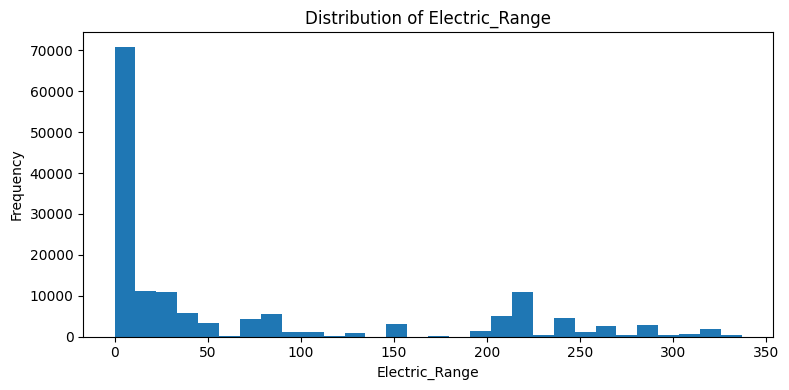

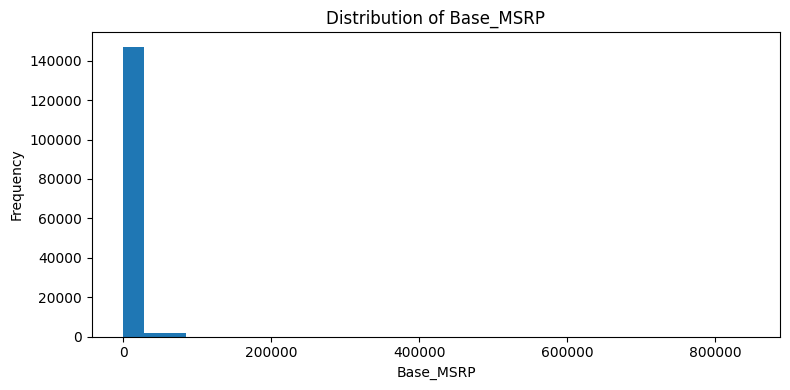

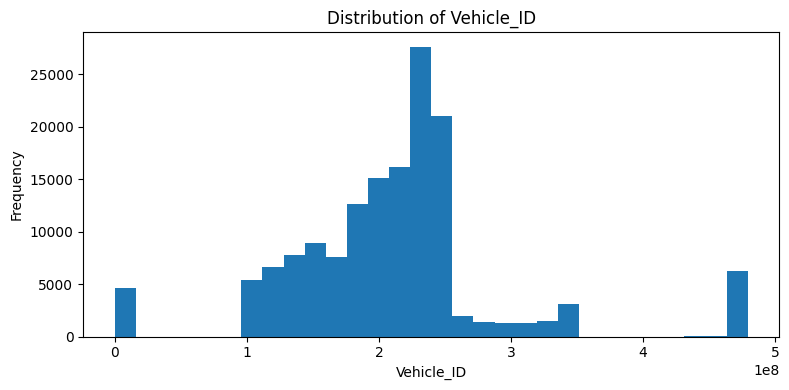

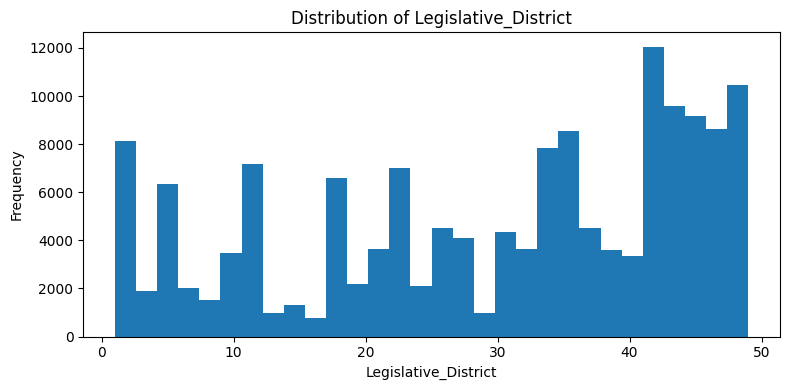

In [11]:
# Histograms for numerical variables
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# 6. Categorical Frequency and Proportion Analysis

For a category with count \(f_i\):

\[
Proportion_i = \frac{f_i}{N}
\]

\[
Percentage_i = \frac{f_i}{N}\times100
\]

This is the primary statistical approach for `Make`, `State`, `EV_Type`, `CAFV_Eligibility`, and similar categorical variables.


In [12]:
# Frequency + percentage for every categorical column
for col in categorical_cols:
    freq = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(dropna=False, normalize=True).mul(100)

    table = pd.DataFrame({
        "Count": freq,
        "Percentage": pct.round(4)
    })

    print(f"\n{'='*70}\n{col}\n{'='*70}")
    display(table.head(20))



VIN


,Count,Percentage
VIN,,
7SAYGDEE7P,807,0.5363
7SAYGDEE6P,802,0.5330
7SAYGDEE8P,775,0.5150
7SAYGDEE2P,775,0.5150
7SAYGDEEXP,772,0.5130
7SAYGDEE0P,763,0.5070
7SAYGDEE5P,762,0.5064
7SAYGDEE9P,756,0.5024
7SAYGDEE4P,744,0.4944



County


,Count,Percentage
County,,
King,79078,52.5498
Snohomish,17307,11.5010
Pierce,11542,7.6700
Clark,8855,5.8844
Thurston,5403,3.5905
Kitsap,4923,3.2715
Spokane,3690,2.4521
Whatcom,3668,2.4375
Benton,1801,1.1968



City


...

,Count,Percentage
Vehicle_Location,,
POINT (-122.12302 47.67668),3876,2.5757
POINT (-122.1876761 47.820517),2753,1.8295
POINT (-122.20264 47.6785),2619,1.7404
POINT (-122.16937 47.571015),2457,1.6328
POINT (-122.201905 47.61385),2456,1.6321
POINT (-122.3185 47.67949),2359,1.5676
POINT (-122.0313266 47.6285782),2141,1.4228
POINT (-122.151665 47.75855),2095,1.3922
POINT (-122.2377542 47.582905),2083,1.3842



Electric_Utility


,Count,Percentage
Electric_Utility,,
PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),55637,36.9725
PUGET SOUND ENERGY INC,29865,19.8462
CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),27268,18.1204
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLARK COUNTY - (WA),8643,5.7435
BONNEVILLE POWER ADMINISTRATION||CITY OF TACOMA - (WA)||PENINSULA LIGHT COMPANY,6622,4.4005
PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM COUNTY,3443,2.2880
BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||INLAND POWER & LIGHT COMPANY,2244,1.4912
BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOHOMISH COUNTY,1341,0.8911
PACIFICORP,1102,0.7323



Census_Tract


,Count,Percentage
Census_Tract,,
"53,033,028,200.0000",1734,1.1523
"53,033,028,500.0000",960,0.6380
"53,033,032,321.0000",697,0.4632
"53,033,009,300.0000",544,0.3615
"53,033,026,200.0000",519,0.3449
"53,067,011,200.0000",518,0.3442
"53,033,024,500.0000",484,0.3216
"53,033,032,318.0000",477,0.3170
"53,033,005,600.0000",471,0.3130


# 7. Confidence Intervals

For a mean with sufficiently large sample size, a common confidence interval is:

\[
\bar{x} \pm t_{\alpha/2,n-1}\frac{s}{\sqrt{n}}
\]

A 95% confidence interval uses \(\alpha=0.05\).

Interpretation: the interval describes uncertainty in the estimated population mean under the assumptions of the procedure. It is not a statement that 95% of individual observations lie inside the interval.


In [13]:
# 95% CI for the mean of every numerical variable
ci_rows = []

for col in numeric_cols:
    x = df[col].dropna()
    n = len(x)
    mean = x.mean()
    se = stats.sem(x)
    ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

    ci_rows.append({
        "Column": col,
        "N": n,
        "Mean": mean,
        "SE": se,
        "CI_95_Lower": ci_low,
        "CI_95_Upper": ci_high
    })

ci_table = pd.DataFrame(ci_rows)
display(ci_table)


,Column,N,Mean,SE,CI_95_Lower,CI_95_Upper
0,Model_Year,150482,"2,020.0054",0.0078,"2,019.9902","2,020.0207"
1,Electric_Range,150482,67.8778,0.2481,67.3916,68.3640
2,Base_MSRP,150482,"1,312.6447",23.7969,"1,266.0032","1,359.2863"
3,Vehicle_ID,150482,"211,112,233.3464","211,290.6259","210,698,107.9984","211,526,358.6943"
4,Legislative_District,150482,29.3522,0.0382,29.2774,29.4271


# 8. One-Sample Hypothesis Testing

General structure:

- **H0 (null):** population parameter equals a benchmark.
- **H1 (alternative):** population parameter differs from the benchmark.

One-sample t statistic:

\[
t = \frac{\bar{x}-\mu_0}{s/\sqrt{n}}
\]

Use a benchmark that has a meaningful business or domain interpretation. Do not invent a benchmark merely to obtain a significant p-value.


In [14]:
# Example framework: test Electric_Range against a chosen business benchmark
# Replace benchmark only when a defensible business benchmark exists.

if "Electric_Range" in df.columns:
    range_sample = df["Electric_Range"].dropna()
    benchmark = range_sample.median()  # neutral demonstration benchmark

    result = stats.ttest_1samp(range_sample, popmean=benchmark)

    print("Benchmark:", benchmark)
    print("t-statistic:", result.statistic)
    print("p-value:", result.pvalue)


Benchmark: 18.0
t-statistic: 201.06634489336466
p-value: 0.0


# 9. Two-Sample Independent t-Test

Use when comparing the means of a numerical variable across **two independent groups**.

Welch's t-test is generally preferable when equal variances cannot be assumed.

\[
t = \frac{\bar{x}_1-\bar{x}_2}
{\sqrt{s_1^2/n_1+s_2^2/n_2}}
\]

Example business question:

> Is average electric range different between BEV and PHEV vehicles?

Before interpreting the result, inspect sample sizes, distributions, outliers, and the meaning of the groups.


In [15]:
# Welch's t-test: Electric_Range by EV_Type, if at least two groups exist
if {"Electric_Range", "EV_Type"}.issubset(df.columns):
    groups = [
        g["Electric_Range"].dropna()
        for _, g in df.groupby("EV_Type")
    ]
    labels = df["EV_Type"].dropna().value_counts().index.tolist()

    if len(groups) >= 2:
        a, b = groups[0], groups[1]
        result = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")

        print("Groups:", labels[:2])
        print("Welch t-statistic:", result.statistic)
        print("p-value:", result.pvalue)


Groups: ['Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)']
Welch t-statistic: 147.91612601278496
p-value: 0.0


# 10. Effect Size — Cohen's d

Statistical significance can be driven by a very large sample.

For two independent groups:

\[
d = \frac{\bar{x}_1-\bar{x}_2}{s_{pooled}}
\]

A rough convention is:
- 0.2 → small
- 0.5 → medium
- 0.8 → large

These thresholds are context-dependent. Report the actual effect size rather than relying only on labels.


In [16]:
def cohens_d(x, y):
    x = pd.Series(x).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)

    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(
        ((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1))
        / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled_sd


if {"Electric_Range", "EV_Type"}.issubset(df.columns):
    groups = [
        g["Electric_Range"].dropna()
        for _, g in df.groupby("EV_Type")
    ]

    if len(groups) >= 2:
        print("Cohen's d:", cohens_d(groups[0], groups[1]))


Cohen's d: 0.509427458525707


# 11. ANOVA

One-way ANOVA compares the means of a numerical variable across three or more independent groups.

\[
F = \frac{MS_{between}}{MS_{within}}
\]

Null hypothesis:

\[
H_0: \mu_1=\mu_2=...=\mu_k
\]

A significant ANOVA result tells us that at least one group differs, but not which groups differ. Post-hoc analysis is required for pairwise conclusions.


In [17]:
# One-way ANOVA: Electric_Range across EV_Type
if {"Electric_Range", "EV_Type"}.issubset(df.columns):
    grouped = [
        g["Electric_Range"].dropna()
        for _, g in df.groupby("EV_Type")
        if len(g["Electric_Range"].dropna()) > 1
    ]

    if len(grouped) >= 3:
        result = stats.f_oneway(*grouped)
        print("F-statistic:", result.statistic)
        print("p-value:", result.pvalue)
    else:
        print("Need at least 3 usable groups for this ANOVA example.")


Need at least 3 usable groups for this ANOVA example.


# 12. Chi-Square Test of Independence

For two categorical variables, test whether they are statistically associated.

\[
\chi^2 = \sum \frac{(O-E)^2}{E}
\]

where:
- O = observed frequency
- E = expected frequency

Example:
`EV_Type` × `State`

A significant result indicates association, not causation.


In [18]:
# Crosstab + chi-square test
if {"EV_Type", "State"}.issubset(df.columns):
    contingency = pd.crosstab(df["EV_Type"], df["State"])

    chi2, p, dof, expected = stats.chi2_contingency(contingency)

    print("Chi-square:", chi2)
    print("Degrees of freedom:", dof)
    print("p-value:", p)

    expected_df = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )

    display(contingency.head())
    display(expected_df.head())


Chi-square: 78.70969867876227
Degrees of freedom: 40
p-value: 0.00024995044281763844


State,AK,AL,AP,AR,AZ,BC,CA,CO,CT,DC,DE,FL,GA,HI,ID,IL,IN,KS,KY,LA,MA,MD,MN,MO,MS,MT,NC,NE,NH,NJ,NV,NY,OH,OR,PA,SC,TX,UT,VA,WA,WY
EV_Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Battery Electric Vehicle (BEV),1,3,1,2,6,2,61,9,1,5,1,6,4,4,2,9,1,1,2,3,2,18,1,3,1,0,9,2,1,5,4,5,2,3,2,3,14,1,20,116585,2
Plug-in Hybrid Electric Vehicle (PHEV),0,0,0,0,5,0,31,2,6,0,0,3,1,4,0,3,1,1,1,0,1,15,0,1,0,1,4,1,0,4,2,2,0,5,0,3,6,1,15,33556,0


State,AK,AL,AP,AR,AZ,BC,CA,CO,CT,DC,DE,FL,GA,HI,ID,IL,IN,KS,KY,LA,MA,MD,MN,MO,MS,MT,NC,NE,NH,NJ,NV,NY,OH,OR,PA,SC,TX,UT,VA,WA,WY
EV_Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Battery Electric Vehicle (BEV),0.7762,2.3287,0.7762,1.5524,8.5384,1.5524,71.4122,8.5384,5.4335,3.8811,0.7762,6.9860,3.8811,6.2098,1.5524,9.3146,1.5524,1.5524,2.3287,2.3287,2.3287,25.6152,0.7762,3.1049,0.7762,0.7762,10.0908,2.3287,0.7762,6.9860,4.6573,5.4335,1.5524,6.2098,1.5524,4.6573,15.5244,1.5524,27.1677,"116,542.3093",1.5524
Plug-in Hybrid Electric Vehicle (PHEV),0.2238,0.6713,0.2238,0.4476,2.4616,0.4476,20.5878,2.4616,1.5665,1.1189,0.2238,2.0140,1.1189,1.7902,0.4476,2.6854,0.4476,0.4476,0.6713,0.6713,0.6713,7.3848,0.2238,0.8951,0.2238,0.2238,2.9092,0.6713,0.2238,2.0140,1.3427,1.5665,0.4476,1.7902,0.4476,1.3427,4.4756,0.4476,7.8323,"33,598.6907",0.4476


# 13. Cramér's V — Categorical Effect Size

For a contingency table:

\[
V = \sqrt{\frac{\chi^2}{n\times\min(r-1,c-1)}}
\]

Cramér's V measures the strength of association between categorical variables. It should be reported alongside the chi-square p-value.


In [19]:
def cramers_v(table):
    chi2 = stats.chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, c = table.shape

    if n == 0 or min(r - 1, c - 1) == 0:
        return np.nan

    return np.sqrt(chi2 / (n * min(r - 1, c - 1)))


if {"EV_Type", "State"}.issubset(df.columns):
    ct = pd.crosstab(df["EV_Type"], df["State"])
    print("Cramér's V:", cramers_v(ct))


Cramér's V: 0.022870299268562398


# 14. Correlation Analysis

### Pearson correlation

Measures linear association:

\[
r =
\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum(x_i-\bar{x})^2\sum(y_i-\bar{y})^2}}
\]

### Spearman correlation

Uses ranks and is useful for monotonic relationships when Pearson assumptions are unsuitable.

**Important:** correlation does not prove causation.


In [20]:
# Pearson correlation matrix
pearson_corr = df[numeric_cols].corr(method="pearson")
display(pearson_corr)


,Model_Year,Electric_Range,Base_MSRP,Vehicle_ID,Legislative_District
Model_Year,1.0000,-0.4313,-0.2318,0.0550,-0.0100
Electric_Range,-0.4313,1.0000,0.1037,-0.0514,0.0234
Base_MSRP,-0.2318,0.1037,1.0000,-0.0160,0.0126
Vehicle_ID,0.0550,-0.0514,-0.0160,1.0000,-0.0075
Legislative_District,-0.0100,0.0234,0.0126,-0.0075,1.0000


In [21]:
# Spearman correlation matrix
spearman_corr = df[numeric_cols].corr(method="spearman")
display(spearman_corr)


,Model_Year,Electric_Range,Base_MSRP,Vehicle_ID,Legislative_District
Model_Year,1.0000,-0.6964,-0.1942,0.2846,-0.0097
Electric_Range,-0.6964,1.0000,0.1102,-0.1502,-0.0001
Base_MSRP,-0.1942,0.1102,1.0000,-0.0262,0.0111
Vehicle_ID,0.2846,-0.1502,-0.0262,1.0000,-0.0160
Legislative_District,-0.0097,-0.0001,0.0111,-0.0160,1.0000


In [22]:
# Pairwise correlation tests with p-values
corr_rows = []

for i, col1 in enumerate(numeric_cols):
    for col2 in numeric_cols[i+1:]:
        temp = df[[col1, col2]].dropna()

        if len(temp) >= 3:
            r, p = stats.pearsonr(temp[col1], temp[col2])
            corr_rows.append({
                "Variable_1": col1,
                "Variable_2": col2,
                "Pearson_r": r,
                "p_value": p,
                "N": len(temp)
            })

corr_tests = pd.DataFrame(corr_rows).sort_values("p_value")
display(corr_tests)


,Variable_1,Variable_2,Pearson_r,p_value,N
0,Model_Year,Electric_Range,-0.4313,0.0000,150482
1,Model_Year,Base_MSRP,-0.2318,0.0000,150482
4,Electric_Range,Base_MSRP,0.1037,0.0000,150482
2,Model_Year,Vehicle_ID,0.0550,0.0000,150482
5,Electric_Range,Vehicle_ID,-0.0514,0.0000,150482
6,Electric_Range,Legislative_District,0.0234,0.0000,150482
7,Base_MSRP,Vehicle_ID,-0.0160,0.0000,150482
8,Base_MSRP,Legislative_District,0.0126,0.0000,150482
3,Model_Year,Legislative_District,-0.0100,0.0001,150482
9,Vehicle_ID,Legislative_District,-0.0075,0.0036,150482


# 15. Normality Diagnostics

Normality tests can become overly sensitive with very large datasets.

Use them together with:
- histogram
- Q-Q plot
- skewness
- kurtosis
- sample size
- practical context

The Shapiro-Wilk test is demonstrated on a sample because applying it blindly to a very large dataset is often impractical.


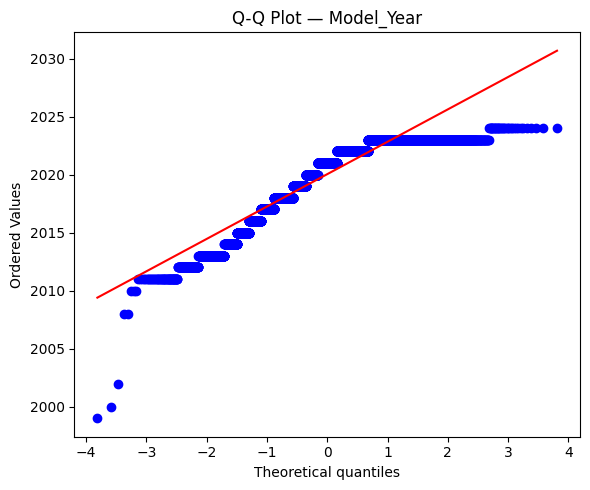

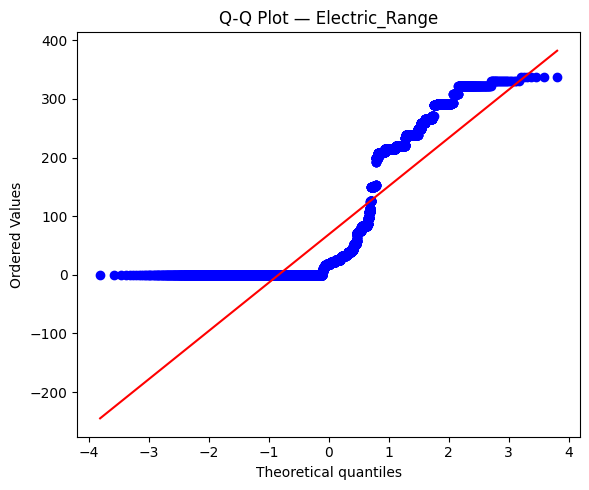

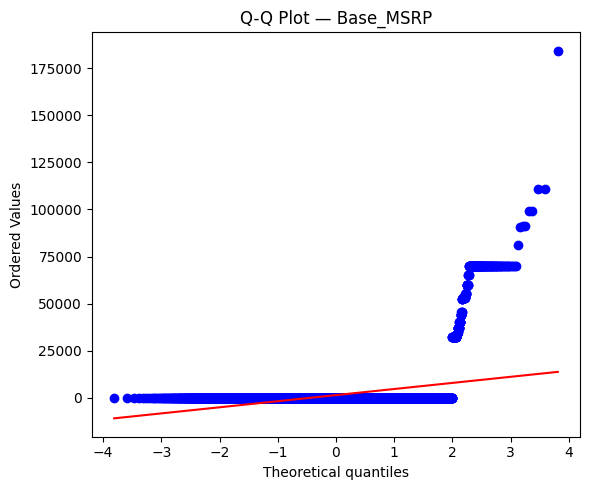

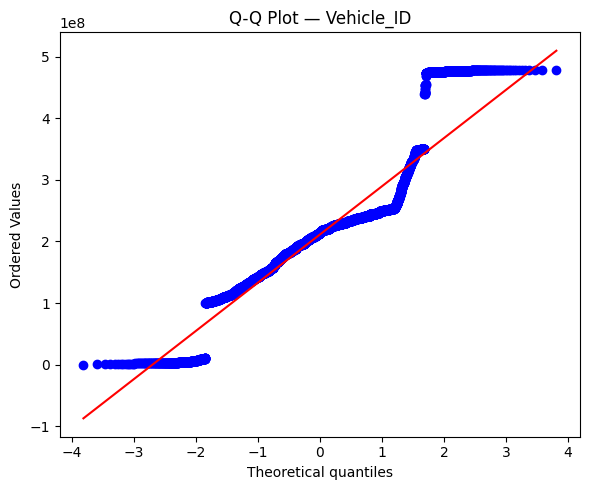

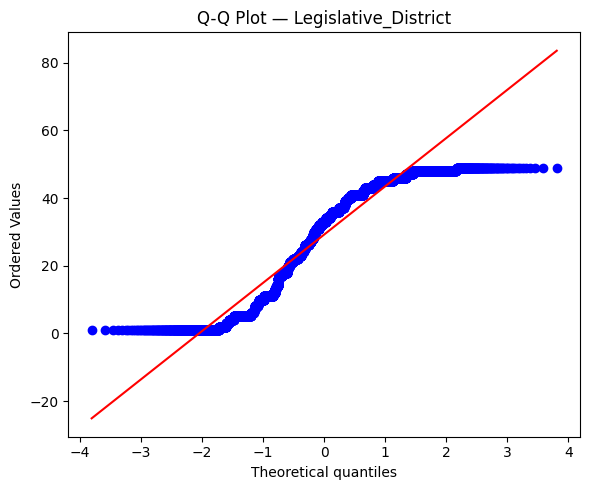

In [23]:
# Q-Q plots for numerical variables
for col in numeric_cols:
    x = df[col].dropna()

    plt.figure(figsize=(6, 5))
    stats.probplot(x.sample(min(len(x), 10000), random_state=42), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot — {col}")
    plt.tight_layout()
    plt.show()


In [24]:
# Shapiro-Wilk on a capped random sample
normality_rows = []

for col in numeric_cols:
    x = df[col].dropna()
    sample = x.sample(min(len(x), 5000), random_state=42)

    if len(sample) >= 3:
        stat, p = stats.shapiro(sample)
        normality_rows.append({
            "Column": col,
            "Sample_N": len(sample),
            "Shapiro_W": stat,
            "p_value": p
        })

display(pd.DataFrame(normality_rows))


,Column,Sample_N,Shapiro_W,p_value
0,Model_Year,5000,0.8773,0.0000
1,Electric_Range,5000,0.7241,0.0000
2,Base_MSRP,5000,0.1254,0.0000
3,Vehicle_ID,5000,0.8773,0.0000
4,Legislative_District,5000,0.9134,0.0000


# 16. Variance / Homogeneity Tests

For group comparisons, variance assumptions can matter.

### Levene's test

Null hypothesis:

\[
H_0: \sigma_1^2=\sigma_2^2=...=\sigma_k^2
\]

A non-significant result provides no evidence against equal variances, while a significant result suggests unequal variance.


In [25]:
# Levene's test across EV types
if {"Electric_Range", "EV_Type"}.issubset(df.columns):
    samples = [
        g["Electric_Range"].dropna()
        for _, g in df.groupby("EV_Type")
        if len(g["Electric_Range"].dropna()) > 1
    ]

    if len(samples) >= 2:
        result = stats.levene(*samples, center="median")
        print("Levene statistic:", result.statistic)
        print("p-value:", result.pvalue)


Levene statistic: 13414.48374391066
p-value: 0.0


# 17. Non-Parametric Tests

When parametric assumptions are poor or data is strongly non-normal, non-parametric alternatives can be useful.

### Mann-Whitney U
Two independent groups.

### Kruskal-Wallis H
Three or more independent groups.

These tests generally compare distributions/ranks rather than directly testing equality of means.


In [26]:
# Mann-Whitney U example
if {"Electric_Range", "EV_Type"}.issubset(df.columns):
    samples = [
        g["Electric_Range"].dropna()
        for _, g in df.groupby("EV_Type")
    ]

    if len(samples) >= 2:
        result = stats.mannwhitneyu(
            samples[0], samples[1],
            alternative="two-sided"
        )
        print("Mann-Whitney U:", result.statistic)
        print("p-value:", result.pvalue)


Mann-Whitney U: 1579727492.5
p-value: 0.0


In [27]:
# Kruskal-Wallis example
if {"Electric_Range", "EV_Type"}.issubset(df.columns):
    samples = [
        g["Electric_Range"].dropna()
        for _, g in df.groupby("EV_Type")
        if len(g["Electric_Range"].dropna()) > 1
    ]

    if len(samples) >= 3:
        result = stats.kruskal(*samples)
        print("Kruskal-Wallis H:", result.statistic)
        print("p-value:", result.pvalue)


# 18. Bootstrap Confidence Interval

Bootstrap resampling repeatedly samples observations with replacement.

For an estimated statistic \(\hat{\theta}\), the bootstrap approximates its sampling distribution without relying heavily on a theoretical distribution.

Workflow:

```text
Original sample
      ↓
Resample with replacement
      ↓
Calculate statistic
      ↓
Repeat many times
      ↓
Bootstrap distribution
      ↓
Confidence interval
```


In [28]:
# Bootstrap 95% CI for mean Electric_Range
if "Electric_Range" in df.columns:
    x = df["Electric_Range"].dropna().to_numpy()
    rng = np.random.default_rng(42)

    n_boot = 2000
    boot_means = np.empty(n_boot)

    for i in range(n_boot):
        sample = rng.choice(x, size=len(x), replace=True)
        boot_means[i] = sample.mean()

    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    print("Original mean:", x.mean())
    print("Bootstrap 95% CI:", (ci_low, ci_high))


Original mean: 67.87783921000518
Bootstrap 95% CI: (np.float64(67.355321566699), np.float64(68.35078913092596))


# 19. Empirical Rule / Z-Scores

For a value x:

\[
z = \frac{x-\mu}{\sigma}
\]

A z-score measures how many standard deviations an observation lies from the mean.

Do not automatically delete observations with large z-scores; investigate whether they represent valid rare cases.


In [29]:
# Z-score summary
zscore_summary = []

for col in numeric_cols:
    x = df[col].dropna()
    z = stats.zscore(x, nan_policy="omit")

    zscore_summary.append({
        "Column": col,
        "Abs_Z_gt_2": np.sum(np.abs(z) > 2),
        "Abs_Z_gt_3": np.sum(np.abs(z) > 3),
        "Abs_Z_gt_3_%": np.mean(np.abs(z) > 3) * 100
    })

display(pd.DataFrame(zscore_summary))


,Column,Abs_Z_gt_2,Abs_Z_gt_3,Abs_Z_gt_3_%
0,Model_Year,7055,60,0.0399
1,Electric_Range,7928,0,0.0000
2,Base_MSRP,3455,3455,2.2960
3,Vehicle_ID,11036,6251,4.1540
4,Legislative_District,0,0,0.0000


# 20. Group-Level Statistical Summary

For business analytics, statistics become more useful when segmented by meaningful groups.

Examples:
- Electric range by EV type
- MSRP by manufacturer
- EV counts by state
- Range by model year
- Manufacturer share by state

The key is to compare distributions and sample sizes, not just a single average.


In [30]:
# Numerical summary by EV type
if "EV_Type" in df.columns:
    ev_type_stats = df.groupby("EV_Type")[numeric_cols].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )
    display(ev_type_stats)


Model_Year                        \
                                            count       mean     median   
EV_Type                                                                   
Battery Electric Vehicle (BEV)             116807 2,020.3135 2,021.0000   
Plug-in Hybrid Electric Vehicle (PHEV)      33675 2,018.9370 2,019.0000   

                                                          Electric_Range  \
                                          std   min   max          count   
EV_Type                                                                    
Battery Electric Vehicle (BEV)         2.8570  1997  2024         116807   
Plug-in Hybrid Electric Vehicle (PHEV) 3.2929  2010  2024          33675   

                                                                          \
                                          mean  median      std min  max   
EV_Type                                                                    
Battery Electric Vehicle (BEV)         78.6089  0.0000 106.4766   0  337   
Plug-in Hybrid Electric Vehicle (PHEV) 30.6555 26.0000  16.4561   6  153   

                                       Base_MSRP                    \
                                           count       mean median   
EV_Type                                                              
Battery Electric Vehicle (BEV)            116807 1,146.2314 0.0000   
Plug-in Hybrid Electric Vehicle (PHEV)     33675 1,889.8754 0.0000   

                                                               Vehicle_ID  \
                                               std min     max      count   
EV_Type                                                                     
Battery Electric Vehicle (BEV)          8,553.8266   0  110950     116807   
Plug-in Hybrid Electric Vehicle (PHEV) 11,251.0247   0  845000      33675   

                                                                          \
                                                   mean           median   
EV_Type                                                                    
Battery Electric Vehicle (BEV)         211,169,640.5220 216,863,167.0000   
Plug-in Hybrid Electric Vehicle (PHEV) 210,913,107.5864 209,325,336.0000   

                                                                         \
                                                   std   min        max   
EV_Type                                                                   
Battery Electric Vehicle (BEV)         81,319,288.7848  4777  479114996   
Plug-in Hybrid Electric Vehicle (PHEV) 84,162,418.4491  4385  479254772   

                                       Legislative_District                  \
                                                      count    mean  median   
EV_Type                                                                       
Battery Electric Vehicle (BEV)                       116807 29.8558 34.0000   
Plug-in Hybrid Electric Vehicle (PHEV)                33675 27.6056 30.0000   

                                                        
                                           std min max  
EV_Type                                                 
Battery Electric Vehicle (BEV)         14.8698   1  49  
Plug-in Hybrid Electric Vehicle (PHEV) 14.4612   1  49

In [31]:
# Numerical summary by manufacturer
if "Make" in df.columns:
    make_stats = df.groupby("Make")[numeric_cols].agg(
        ["count", "mean", "median", "std"]
    )
    display(make_stats.head(20))


Model_Year                              Electric_Range  \
                    count       mean     median    std          count   
Make                                                                    
ALFA ROMEO             12 2,024.0000 2,024.0000 0.0000             12   
AUDI                 3006 2,020.4830 2,021.0000 2.1955           3006   
AZURE DYNAMICS          9 2,011.4444 2,011.0000 0.5270              9   
BENTLEY                 2 2,021.5000 2,021.5000 0.7071              2   
BMW                  6439 2,019.7023 2,021.0000 3.1196           6439   
CADILLAC              176 2,019.0455 2,018.0000 4.3343            176   
CHEVROLET           12026 2,018.1875 2,018.0000 3.3044          12026   
CHRYSLER             2642 2,020.7218 2,021.0000 1.9645           2642   
FIAT                  806 2,015.4690 2,015.0000 1.5220            806   
FISKER                 17 2,012.0000 2,012.0000 0.0000             17   
FORD                 7614 2,018.9014 2,021.0000 3.6697           7614   
GENESIS               107 2,023.0000 2,023.0000 0.0000            107   
HONDA                 810 2,018.3235 2,018.0000 0.8763            810   
HYUNDAI              3171 2,022.1025 2,023.0000 1.4940           3171   
JAGUAR                228 2,019.7105 2,019.0000 1.0172            228   
JEEP                 3292 2,022.4049 2,023.0000 0.8115           3292   
KIA                  6198 2,021.0224 2,022.0000 2.1936           6198   
LAND ROVER             47 2,020.4894 2,020.0000 0.9526             47   
LEXUS                 138 2,022.8116 2,023.0000 0.6456            138   
LINCOLN               229 2,021.7642 2,022.0000 0.9014            229   

                                          Base_MSRP                            \
                   mean   median      std     count         mean       median   
Make                                                                            
ALFA ROMEO      33.0000  33.0000   0.0000        12       0.0000       0.0000   
AUDI            53.5173  16.0000  82.3296      3006       0.0000       0.0000   
AZURE DYNAMICS  56.0000  56.0000   0.0000         9       0.0000       0.0000   
BENTLEY         19.0000  19.0000   2.8284         2       0.0000       0.0000   
BMW             38.1634  30.0000  37.2446      6439   4,154.1233       0.0000   
CADILLAC        19.0795  31.0000  18.3868       176   6,400.1420       0.0000   
CHEVROLET       95.2677  53.0000 101.2468     12026       0.0000       0.0000   
CHRYSLER        32.2430  32.0000   0.4290      2642   1,771.1639       0.0000   
FIAT            85.6266  87.0000   1.4956       806       0.0000       0.0000   
FISKER          33.0000  33.0000   0.0000        17 102,000.0000 102,000.0000   
FORD            13.0239  19.0000  16.5302      7614       0.0000       0.0000   
GENESIS          0.0000   0.0000   0.0000       107       0.0000       0.0000   
HONDA           46.6272  47.0000   3.5674       810       0.0000       0.0000   
HYUNDAI         23.9830   0.0000  65.5148      3171       0.0000       0.0000   
JAGUAR         204.2368 234.0000  78.1378       228       0.0000       0.0000   
JEEP            22.3317  21.0000   1.8433      3292       0.0000       0.0000   
KIA             52.6157  26.0000  79.3733      6198   3,253.0413       0.0000   
LAND ROVER      21.7234  19.0000   9.0258        47       0.0000       0.0000   
LEXUS           22.5217  37.0000  18.1233       138       0.0000       0.0000   
LINCOLN         23.6288  21.0000   3.3973       229       0.0000       0.0000   

                           Vehicle_ID                                    \
                       std      count             mean           median   
Make                                                                      
ALFA ROMEO          0.0000         12 249,270,469.6667 249,884,984.5000   
AUDI                0.0000       3006 197,851,148.5173 201,094,841.0000   
AZURE DYNAMICS      0.0000          9 196,022,693.8889 168,848,459.0000   
BENTLEY             0

In [32]:
# Statistical summary by state
if "State" in df.columns:
    state_stats = df.groupby("State")[numeric_cols].agg(
        ["count", "mean", "median", "std"]
    )
    display(state_stats.head(20))


Model_Year                              Electric_Range           \
           count       mean     median    std          count     mean   
State                                                                   
AK             1 2,021.0000 2,021.0000    NaN              1   0.0000   
AL             3 2,021.3333 2,022.0000 2.0817              3  73.3333   
AP             1 2,013.0000 2,013.0000    NaN              1  75.0000   
AR             2 2,019.5000 2,019.5000 0.7071              2 236.0000   
AZ            11 2,019.8182 2,021.0000 3.1565             11  36.8182   
BC             2 2,013.5000 2,013.5000 7.7782              2 220.0000   
CA            92 2,019.1739 2,020.0000 2.9747             92  69.1957   
CO            11 2,020.0000 2,021.0000 2.8284             11  90.7273   
CT             7 2,017.7143 2,018.0000 3.4017              7  74.4286   
DC             5 2,020.6000 2,020.0000 1.9494              5 152.8000   
DE             1 2,022.0000 2,022.0000    NaN              1   0.0000   
FL             9 2,019.0000 2,020.0000 2.7839              9 123.4444   
GA             5 2,017.4000 2,018.0000 3.3615              5 116.8000   
HI             8 2,018.6250 2,019.0000 2.8754              8 125.6250   
ID             2 2,022.0000 2,022.0000 0.0000              2   0.0000   
IL            12 2,019.5000 2,019.5000 2.5406             12  94.2500   
IN             2 2,019.0000 2,019.0000 2.8284              2 115.5000   
KS             2 2,019.0000 2,019.0000 2.8284              2   7.0000   
KY             3 2,020.0000 2,021.0000 1.7321              3  11.0000   
LA             3 2,022.3333 2,022.0000 0.5774              3   0.0000   

                        Base_MSRP                                      \
        median      std     count        mean      median         std   
State                                                                   
AK      0.0000      NaN         1      0.0000      0.0000         NaN   
AL      0.0000 127.0171         3      0.0000      0.0000      0.0000   
AP     75.0000      NaN         1      0.0000      0.0000         NaN   
AR    236.0000 121.6224         2      0.0000      0.0000      0.0000   
AZ     22.0000  61.2157        11      0.0000      0.0000      0.0000   
BC    220.0000   0.0000         2 49,475.0000 49,475.0000 69,968.2160   
CA     22.0000  92.6019        92  1,998.9130      0.0000 11,167.6682   
CO     32.0000 115.8258        11      0.0000      0.0000      0.0000   
CT     38.0000 109.4301         7      0.0000      0.0000      0.0000   
DC    151.0000 153.6447         5      0.0000      0.0000      0.0000   
DE      0.0000      NaN         1      0.0000      0.0000         NaN   
FL     42.0000 124.8320         9      0.0000      0.0000      0.0000   
GA     84.0000 118.5188         5      0.0000      0.0000      0.0000   
HI    116.5000 116.1070         8      0.0000      0.0000      0.0000   
ID      0.0000   0.0000         2      0.0000      0.0000      0.0000   
IL     30.5000 115.6225        12  3,332.9167      0.0000 11,545.5620   
IN    115.5000 133.6432         2      0.0000      0.0000      0.0000   
KS      7.0000   9.8995         2      0.0000      0.0000      0.0000   
KY      0.0000  19.0526         3      0.0000      0.0000      0.0000   
LA      0.0000   0.0000         3      0.0000      0.0000      0.0000   

      Vehicle_ID                                                     \
           count             mean           median              std   
State                                                                 
AK             1 183,244,330.0000 183,244,330.0000              NaN   
AL             3 242,289,997.3333 249,753,458.0000  14,271,926.6743   
AP             1 112,277,063.0000 112,277,063.0000              NaN   
AR             2 221,499,057.0000 221,499,057.0000   3,038,788.5637   
AZ            11 194,113,009.1818 179,239,910.0000  33,275,494.3675   
BC             2 309,431,937.0000 309,431,937.0000 234,508,977.1615   
CA     

# 21. Confidence Interval by Group

Group means should be accompanied by sample size and uncertainty.

This prevents a small group with an extreme average from being interpreted the same way as a very large group.


In [33]:
def mean_ci_table(data, group_col, value_col, confidence=0.95):
    rows = []

    for group, g in data.groupby(group_col):
        x = g[value_col].dropna()
        n = len(x)

        if n < 2:
            continue

        mean = x.mean()
        se = stats.sem(x)
        low, high = stats.t.interval(
            confidence,
            df=n-1,
            loc=mean,
            scale=se
        )

        rows.append({
            group_col: group,
            "N": n,
            "Mean": mean,
            "CI_Lower": low,
            "CI_Upper": high
        })

    return pd.DataFrame(rows).sort_values("N", ascending=False)


if {"EV_Type", "Electric_Range"}.issubset(df.columns):
    display(mean_ci_table(df, "EV_Type", "Electric_Range"))


,EV_Type,N,Mean,CI_Lower,CI_Upper
0,Battery Electric Vehicle (BEV),116807,78.6089,77.9983,79.2195
1,Plug-in Hybrid Electric Vehicle (PHEV),33675,30.6555,30.4797,30.8312


# 22. Multiple Testing Awareness

When many hypothesis tests are performed, the probability of obtaining at least one apparently significant result by chance increases.

For exploratory analysis:
- report the number of tests
- avoid cherry-picking
- consider false-discovery-rate correction
- distinguish exploratory findings from confirmatory conclusions


In [35]:
# False Discovery Rate (Benjamini-Hochberg) correction

if not corr_tests.empty:

    pvals = corr_tests["p_value"].to_numpy()

    # Adjust p-values using Benjamini-Hochberg method
    p_adjusted = stats.false_discovery_control(
        pvals,
        method="bh"
    )

    corr_tests["p_adjusted"] = p_adjusted

    # Significance after multiple-testing correction
    corr_tests["significant_fdr"] = (
        corr_tests["p_adjusted"] < 0.05
    )

    display(corr_tests)

else:
    print("No correlation tests available.")

,Variable_1,Variable_2,Pearson_r,p_value,N,p_adjusted,significant_fdr
0,Model_Year,Electric_Range,-0.4313,0.0000,150482,0.0000,True
1,Model_Year,Base_MSRP,-0.2318,0.0000,150482,0.0000,True
4,Electric_Range,Base_MSRP,0.1037,0.0000,150482,0.0000,True
2,Model_Year,Vehicle_ID,0.0550,0.0000,150482,0.0000,True
5,Electric_Range,Vehicle_ID,-0.0514,0.0000,150482,0.0000,True
6,Electric_Range,Legislative_District,0.0234,0.0000,150482,0.0000,True
7,Base_MSRP,Vehicle_ID,-0.0160,0.0000,150482,0.0000,True
8,Base_MSRP,Legislative_District,0.0126,0.0000,150482,0.0000,True
3,Model_Year,Legislative_District,-0.0100,0.0001,150482,0.0001,True
9,Vehicle_ID,Legislative_District,-0.0075,0.0036,150482,0.0036,True


# 23. Statistical Significance vs Business Significance

Always separate:

### Statistical significance
Evidence that the observed pattern is unlikely under the null hypothesis.

### Practical / business significance
Whether the size of the difference is large enough to matter operationally.

A huge dataset can make tiny differences statistically significant.

Recommended reporting:

```text
Effect size + confidence interval + p-value + sample size + business interpretation
```


In [36]:
# Compact statistical reporting helper
def interpret_p_value(p, alpha=0.05):
    if pd.isna(p):
        return "Not available"
    return "Statistically significant" if p < alpha else "Not statistically significant"


print(interpret_p_value(0.03))
print(interpret_p_value(0.20))


Statistically significant
Not statistically significant


# 24. Statistical Decision Framework

Use this workflow before selecting a test:

```text
What is the outcome variable?
        ↓
Numeric or categorical?
        ↓
How many groups?
        ↓
Independent or paired?
        ↓
Check distribution / outliers
        ↓
Check variance assumptions where relevant
        ↓
Select parametric or non-parametric method
        ↓
Run test
        ↓
Report effect size + CI + p-value
        ↓
Translate to business insight
```


In [37]:
# Automatic guide for common variables
statistical_guide = pd.DataFrame([
    ["Electric_Range", "Numeric", "Mean/median, CI, t-test, ANOVA, correlation"],
    ["Base_MSRP", "Numeric", "Mean/median, skewness, IQR, CI, group comparison"],
    ["Model_Year", "Discrete numeric", "Frequency, median, grouped trends"],
    ["Make", "Categorical", "Frequency, proportion, ranking, chi-square"],
    ["State", "Categorical", "Frequency, proportion, chi-square"],
    ["EV_Type", "Categorical", "Frequency, proportion, t-test/ANOVA/chi-square"],
    ["CAFV_Eligibility", "Categorical", "Frequency, proportion, chi-square"],
    ["VIN", "Identifier", "Uniqueness / duplicate analysis"],
    ["Vehicle_ID", "Identifier", "Uniqueness / duplicate analysis"],
    ["Postal_Code", "Geographic identifier", "Frequency / geographic grouping"],
    ["Census_Tract", "Geographic identifier", "Frequency / geographic grouping"],
], columns=["Variable", "Type", "Recommended statistical methods"])

display(statistical_guide)


,Variable,Type,Recommended statistical methods
0,Electric_Range,Numeric,"Mean/median, CI, t-test, ANOVA, correlation"
1,Base_MSRP,Numeric,"Mean/median, skewness, IQR, CI, group comparison"
2,Model_Year,Discrete numeric,"Frequency, median, grouped trends"
3,Make,Categorical,"Frequency, proportion, ranking, chi-square"
4,State,Categorical,"Frequency, proportion, chi-square"
5,EV_Type,Categorical,"Frequency, proportion, t-test/ANOVA/chi-square"
6,CAFV_Eligibility,Categorical,"Frequency, proportion, chi-square"
7,VIN,Identifier,Uniqueness / duplicate analysis
8,Vehicle_ID,Identifier,Uniqueness / duplicate analysis
9,Postal_Code,Geographic identifier,Frequency / geographic grouping


# 25. Final Statistical Summary

The final statistical report should contain:

1. Dataset size and valid observations
2. Descriptive statistics
3. Distribution shape
4. Outlier statistics
5. Categorical proportions
6. Confidence intervals
7. Group comparisons
8. Hypothesis-test results
9. Effect sizes
10. Correlation results
11. Important assumptions / limitations
12. Business interpretation

### Final rule

> Never report a p-value alone. A professional analysis explains **what was tested, why it was tested, the effect size, uncertainty, and what the result means for the business**.


In [38]:
# Create a compact statistical profile for export
statistical_profile = desc.copy()

statistical_profile["CV_%"] = (
    statistical_profile["std"] /
    statistical_profile["mean"].replace(0, np.nan) * 100
)

display(statistical_profile)

# Optional export
output_dir = Path("../datas/processed")
output_dir.mkdir(parents=True, exist_ok=True)

statistical_profile.to_csv(
    output_dir / "ev_statistical_profile.csv"
)

print(f"✅ Statistical profile saved to: {(output_dir / 'ev_statistical_profile.csv').resolve()}")


,count,mean,std,min,25%,50%,75%,max,variance,range,skewness,kurtosis,CV_%
Model_Year,"150,482.0000","2,020.0054",3.0152,"1,997.0000","2,018.0000","2,021.0000","2,023.0000","2,024.0000",9.0915,27,-0.9782,0.2354,0.1493
Electric_Range,"150,482.0000",67.8778,96.2300,0.0000,0.0000,18.0000,97.0000,337.0000,"9,260.2146",337,1.2195,-0.0320,141.7694
Base_MSRP,"150,482.0000","1,312.6447","9,231.3102",0.0000,0.0000,0.0000,0.0000,"845,000.0000","85,217,088.2803",845000,11.9309,518.6919,703.2604
Vehicle_ID,"150,482.0000","211,112,233.3464","81,963,879.6419","4,385.0000","169,347,305.2500","215,030,630.0000","239,911,895.5000","479,254,772.0000","6,718,077,565,950,161.0000",479250387,0.8972,3.2904,38.8248
Legislative_District,"150,482.0000",29.3522,14.8090,1.0000,18.0000,33.0000,43.0000,49.0000,219.3078,48,-0.4860,-1.0617,50.4529


✅ Statistical profile saved to: D:\ev_project_v2-Data Analysis\datas\processed\ev_statistical_profile.csv
